# ADS 508 Final Team Project

# Nutri Access Analytics

## Group 3: James Shoenhair, Shery Thaker, and Nancy Walker 

## Introduction 

The goal of this project is to develop a data pipeline and analytical workflow for a hypothetical company focused on improving public health outcomes through data-driven decision-making. This company aims to identify patterns in food access, socioeconomic conditions, and health outcomes to better understand and address disparities across California counties.

To support this objective, we designed a modular Python pipeline using AWS S3 for storage and orchestration of raw and processed data. The pipeline ingests, cleans, and integrates multiple public datasets, including the USDA Food Access Research Atlas, USDA Food Environment Atlas, CDC PLACES dataset, U.S. Census demographic and socioeconomic data, and geospatial retail food location data. Tract-level food access data is retained for exploratory analysis, while county-level features are standardized and merged into a final modeling dataset stored in Parquet format.

### Research Questions:

    - Which communities exhibit characteristics associated with limited access to healthy food resources (i.e., potential food deserts)?

    - How do demographic and socioeconomic factors vary across communities with different levels of food access?

    - Can food environment, demographic, and health-related features be used to predict communities at high risk of limited food access?

    - How do geographic patterns of food access and retail food availability vary across counties, particularly within California?


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import geopandas as gpd

## S3 setup 

This notebook uses datasets generated by the NutriAccess pipeline. The pipeline downloads raw files from S3, preprocesses and standardizes source datasets, aggregates tract-level food access data to the county level where appropriate, and writes cleaned outputs back to S3 under the processedData/ prefix. The final county-level modeling dataset is saved as a Parquet file for efficient downstream analysis.

In [2]:
bucket = os.getenv("S3_BUCKET", "nutriaccess-data")
processed_prefix = "processedData/"

## Load processed files from S3

Pipeline writes ingested data outputs back to S3

### Load Source-level EDA Datasets 

In [3]:
food_access = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_access_clean.csv")
food_access_county = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_access_county_clean.csv")
places = pd.read_csv(f"s3://{bucket}/{processed_prefix}places_ca_health_clean.csv")
food_env = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_environment_clean.csv")
census = pd.read_csv(f"s3://{bucket}/{processed_prefix}census_features_clean.csv")
retail_food = pd.read_csv(f"s3://{bucket}/{processed_prefix}california_food_store_locations.csv")
gdf = gpd.read_file(f"s3://{bucket}/{processed_prefix}california_food_store_locations.geojson")

### Load Final Modeling Dataset 

The final modeling dataset was produced by the pipeline and stored in Parquet format. This file serves as the primary dataset for downstream modeling and county-level analysis.

In [4]:
features = pd.read_parquet(
    f"s3://{bucket}/{processed_prefix}nutriaccess_features.parquet"
)

# Exploratory Data Analysis (MAIN DATASET)

In [5]:
print(features.shape)
features.head()

(58, 29)


,state,county,urban_share,population_2010,avg_poverty_rate,avg_median_family_income,low_income_tracts_count,lila_1_10_count,lila_half_10_count,lila_1_20_count,...,poverty_rate,median_income,bphigh,csmoking,diabetes,lpa,obesity,pct_diabetes_adults19,pct_obese_adults22,povrate21
0,california,alameda,0.983333,1510271,11.179722,112434.352778,151,11,83,11,...,9.2,126240.0,27.50,9.25,10.55,20.35,22.65,7.1,28.1,9.4
1,california,alpine,0.000000,1175,19.800000,82813.000000,0,0,0,0,...,12.3,110781.0,31.80,11.30,10.05,18.70,28.55,7.4,28.1,15.8
2,california,amador,0.000000,38091,10.233333,74668.222222,1,0,0,0,...,7.8,81526.0,33.45,12.30,10.20,21.60,29.55,8.2,28.1,11.1
3,california,butte,0.745098,220000,20.847059,65151.588235,33,14,26,14,...,18.3,68574.0,31.35,13.35,10.30,22.75,29.95,7.4,28.1,16.6
4,california,calaveras,0.200000,45578,12.010000,74331.200000,2,0,0,0,...,13.4,79877.0,33.00,13.65,11.15,23.50,29.80,7.0,28.1,13.5


Final Table is the correct size. 58 counties. California Filter worked. 

In [6]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           58 non-null     object 
 1   county                          58 non-null     object 
 2   urban_share                     58 non-null     float64
 3   population_2010                 58 non-null     int64  
 4   avg_poverty_rate                58 non-null     float64
 5   avg_median_family_income        58 non-null     float64
 6   low_income_tracts_count         58 non-null     int64  
 7   lila_1_10_count                 58 non-null     int64  
 8   lila_half_10_count              58 non-null     int64  
 9   lila_1_20_count                 58 non-null     int64  
 10  total_housing_units_no_vehicle  58 non-null     float64
 11  total_snap_households           58 non-null     float64
 12  tract_count                     58 non

All features have 58 non-null values. Merge was sucessful and dataset has model-ready features. 

In [7]:
# Drop redundant columns 

features = features.drop(columns=["geo_id", "county_name"])

In [8]:
features.isna().sum().sort_values(ascending=False).head(20)

state                             0
county                            0
urban_share                       0
population_2010                   0
avg_poverty_rate                  0
avg_median_family_income          0
low_income_tracts_count           0
lila_1_10_count                   0
lila_half_10_count                0
lila_1_20_count                   0
total_housing_units_no_vehicle    0
total_snap_households             0
tract_count                       0
total_population                  0
male_population                   0
female_population                 0
median_age                        0
poverty_rate                      0
median_income                     0
bphigh                            0
dtype: int64

No null values 

#### Define the Target Variable 

Food Access Risk Lable 

Because a direct label for food insecurity was not available, a proxy target variable was constructed using USDA Food Access indicators. Counties with at least one low-income tract or limited food access tract were labeled as high risk. This binary target enables classification modeling to identify communities most in need of improved food access.

In [9]:
features["high_food_access_risk"] = (
    (features["low_income_tracts_count"] > 0) |
    (features["lila_1_10_count"] > 0)
).astype(int)

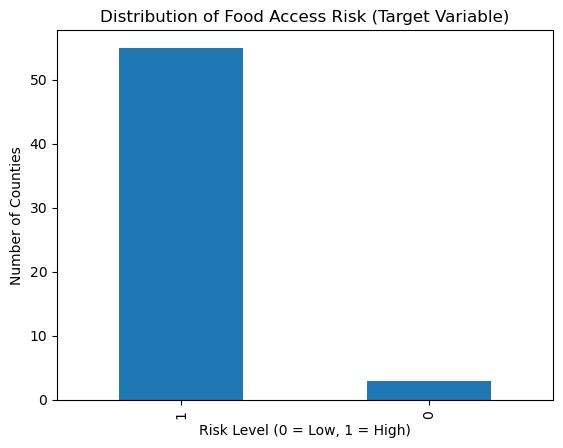

In [10]:
# Target Class distribution 

features["high_food_access_risk"].value_counts().plot(kind="bar")
plt.title("Distribution of Food Access Risk (Target Variable)")
plt.xlabel("Risk Level (0 = Low, 1 = High)")
plt.ylabel("Number of Counties")
plt.show()

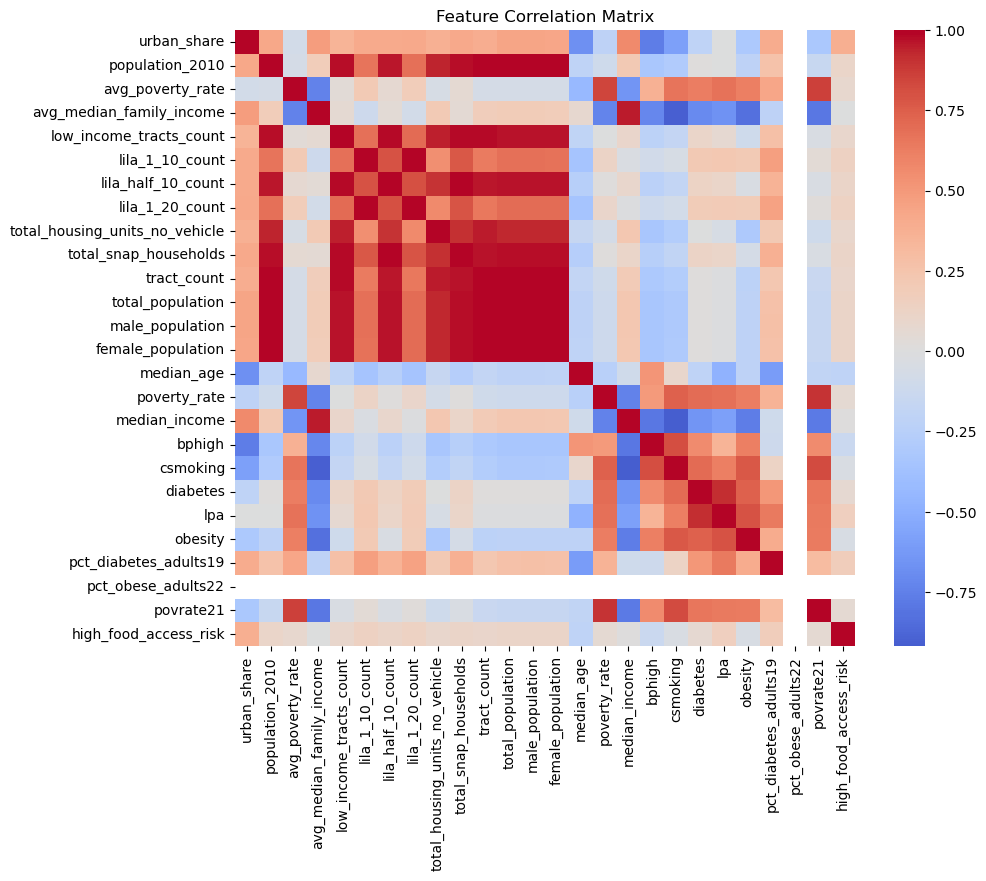

In [11]:
# Check for multicollinearity

plt.figure(figsize=(10,8))
sns.heatmap(features.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## Source-Level EDA

### food_access

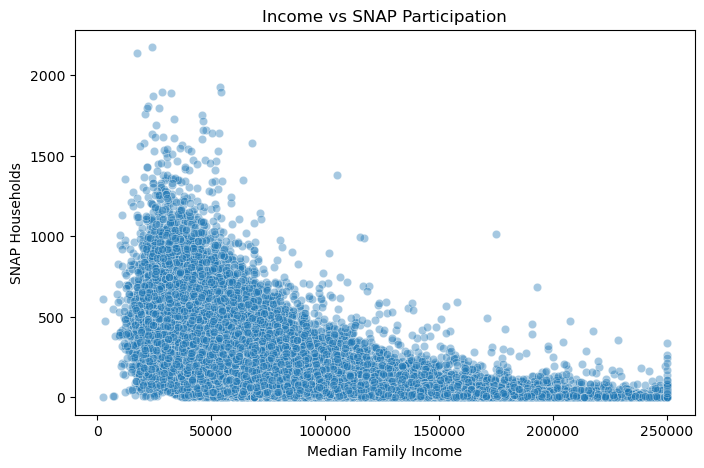

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=food_access,
    x='MedianFamilyIncome',
    y='TractSNAP',
    alpha=0.4
)

plt.title('Income vs SNAP Participation')
plt.xlabel('Median Family Income')
plt.ylabel('SNAP Households')
plt.show()

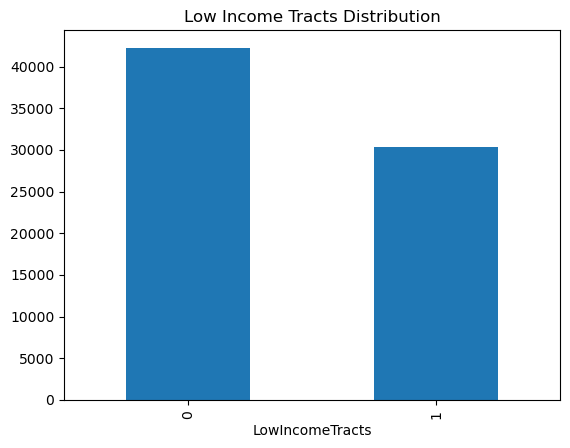

In [13]:
food_access['LowIncomeTracts'].value_counts().plot(kind='bar')
plt.title('Low Income Tracts Distribution')
plt.show()

### Census

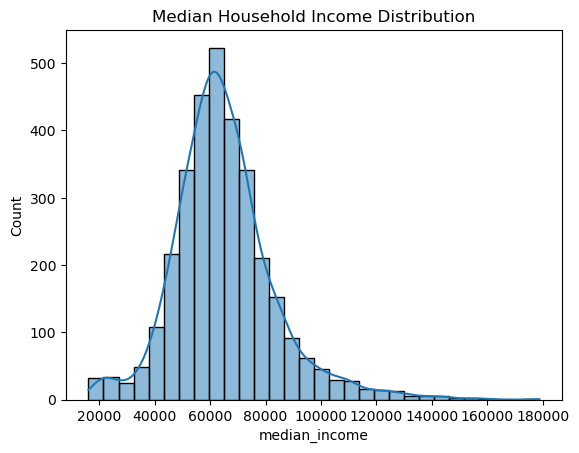

In [14]:
# Income distribution 

sns.histplot(census['median_income'].dropna(), bins=30, kde=True)
plt.title("Median Household Income Distribution")
plt.show()

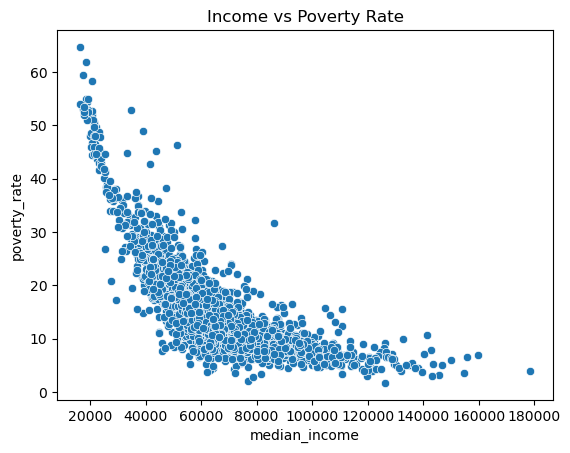

In [15]:
# Povertry vs income 

sns.scatterplot(
    data=census,
    x='median_income',
    y='poverty_rate'
)
plt.title("Income vs Poverty Rate")
plt.show()

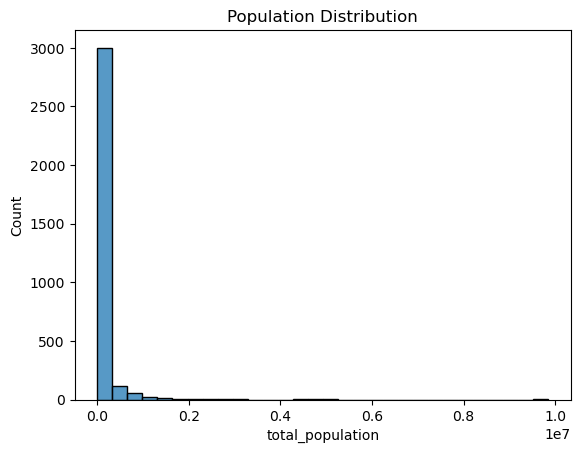

In [16]:
# Population Distribution 

sns.histplot(census['total_population'], bins=30)
plt.title("Population Distribution")
plt.show()

### PLACES

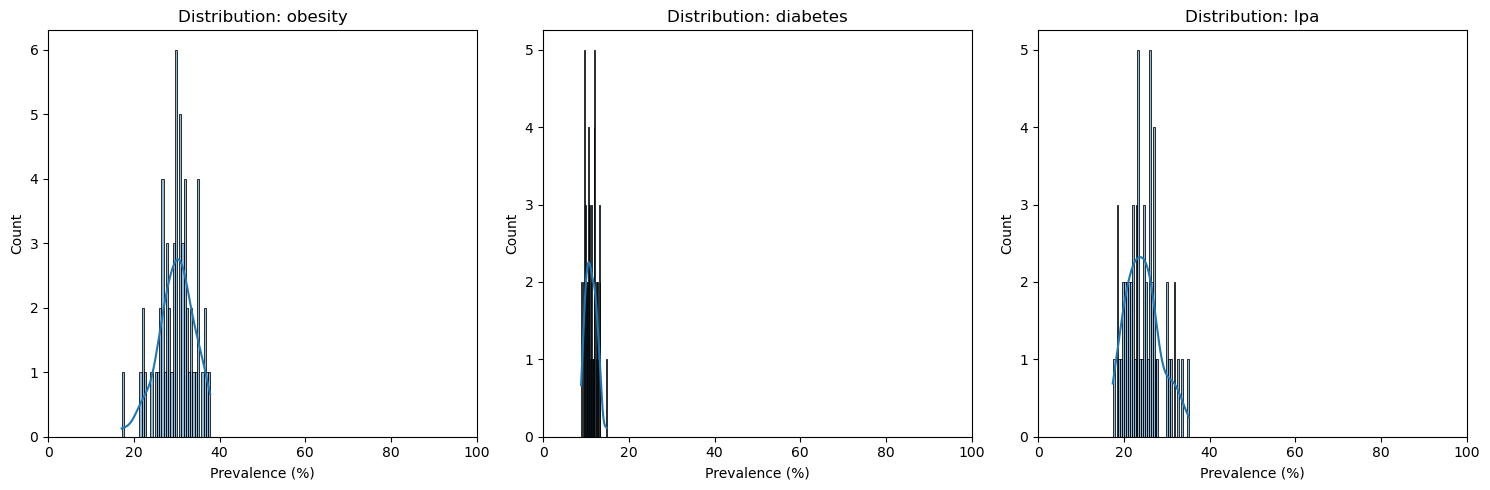

In [17]:
# Distribution of key health metrics

health_measures = ['obesity', 'diabetes', 'lpa']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, measure in zip(axes, health_measures):
    data = places[measure].dropna()
    sns.histplot(data, bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution: {measure}')
    ax.set_xlabel('Prevalence (%)')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [18]:
# California-focused analysis
print(places.columns.tolist())
print(places.head())

ca_places = places.copy()

['state', 'county', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity']
        state     county  bphigh  csmoking  diabetes    lpa  obesity
0  california    alameda   27.50      9.25     10.55  20.35    22.65
1  california     alpine   31.80     11.30     10.05  18.70    28.55
2  california     amador   33.45     12.30     10.20  21.60    29.55
3  california      butte   31.35     13.35     10.30  22.75    29.95
4  california  calaveras   33.00     13.65     11.15  23.50    29.80


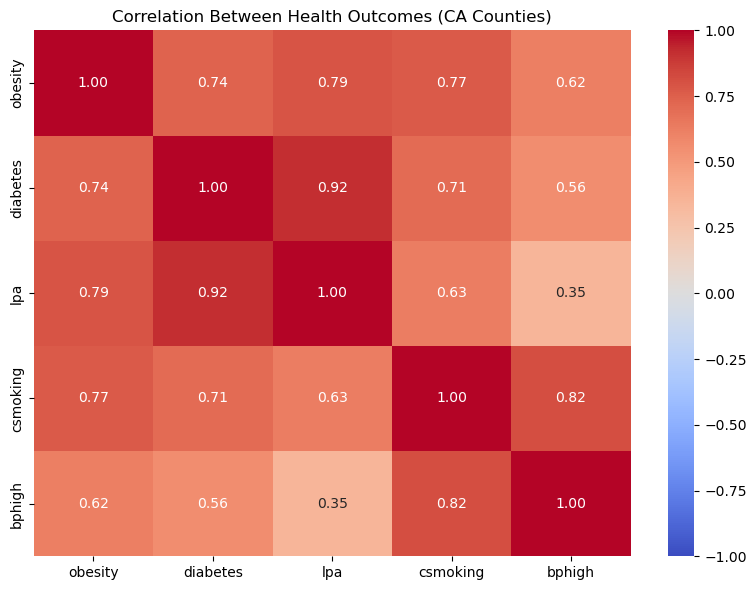

In [19]:
focus = ['obesity', 'diabetes', 'lpa', 'csmoking', 'bphigh']

plt.figure(figsize=(8, 6))
sns.heatmap(
    places[focus].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Health Outcomes (CA Counties)")
plt.tight_layout()
plt.show()

### food_env

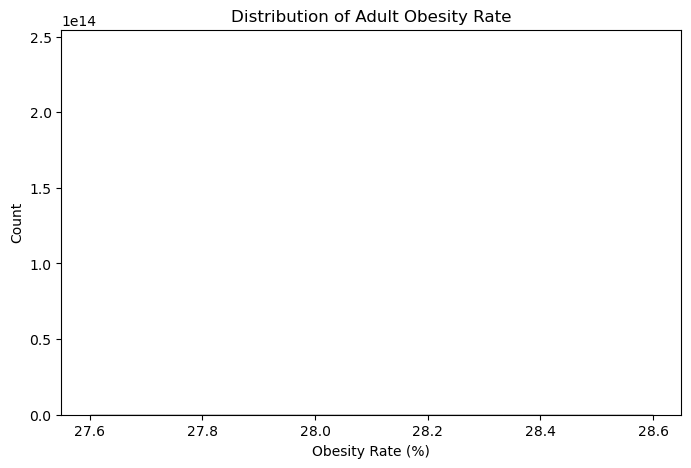

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(food_env['pct_obese_adults22'].dropna(), bins=30, kde=True)
plt.title('Distribution of Adult Obesity Rate')
plt.xlabel('Obesity Rate (%)')
plt.show()

<Axes: xlabel='povrate21', ylabel='pct_diabetes_adults19'>

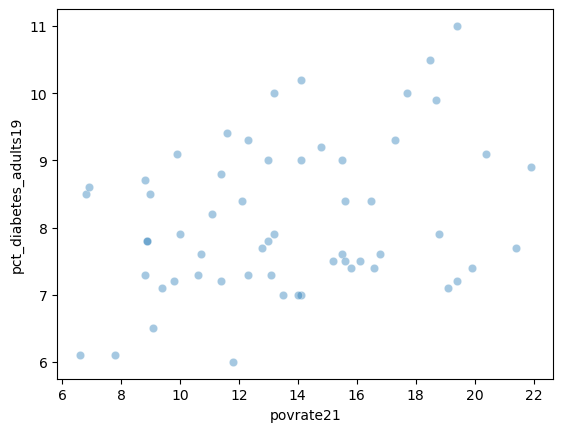

In [21]:
sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

In [22]:
### retail_food

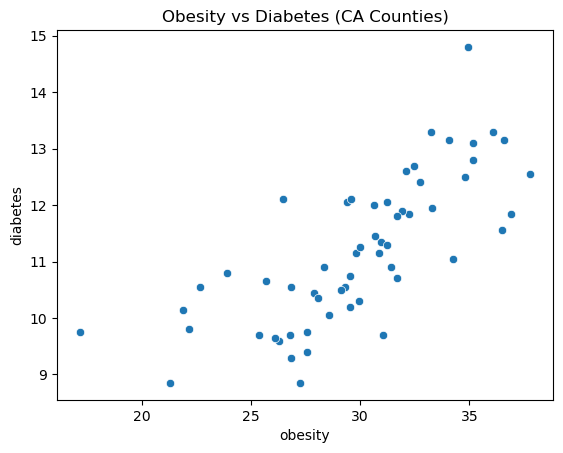

In [23]:
sns.scatterplot(
    data=ca_places,
    x='obesity',
    y='diabetes'
)
plt.title("Obesity vs Diabetes (CA Counties)")
plt.show()

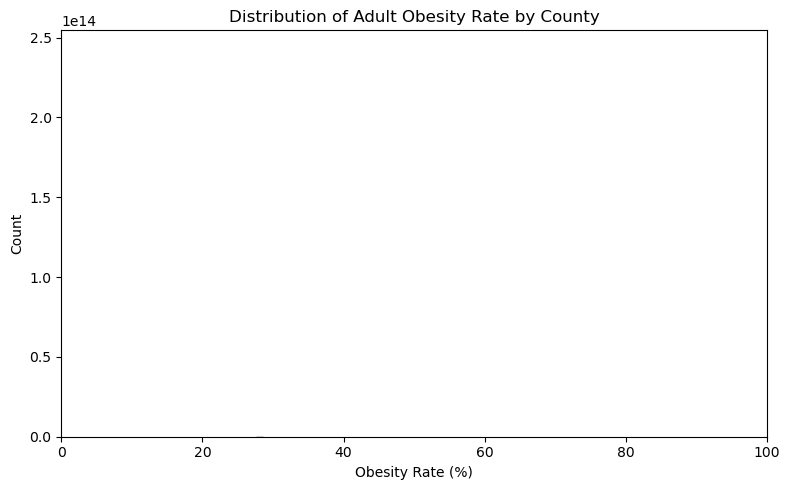

In [24]:
# Obesity Distribution

plt.figure(figsize=(8, 5))
sns.histplot(food_env['pct_obese_adults22'].dropna(), bins=30, kde=True)

plt.title('Distribution of Adult Obesity Rate by County')
plt.xlabel('Obesity Rate (%)')
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

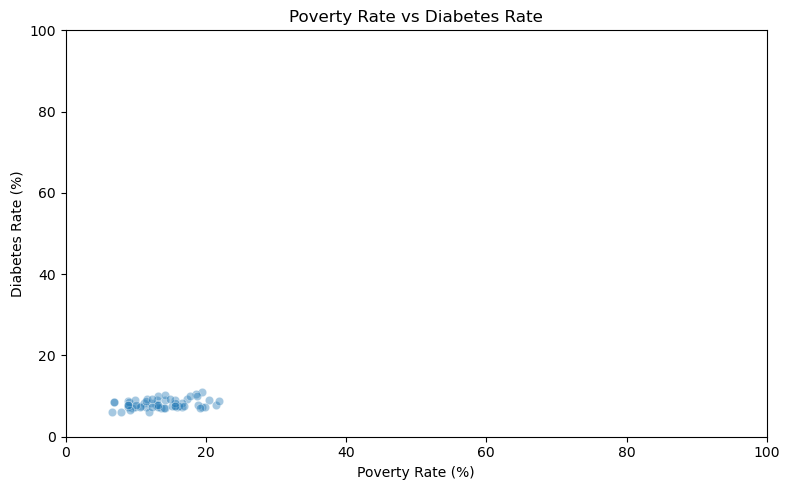

In [25]:
# Poverty vs Diabetes Scatter

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

plt.title('Poverty Rate vs Diabetes Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Diabetes Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

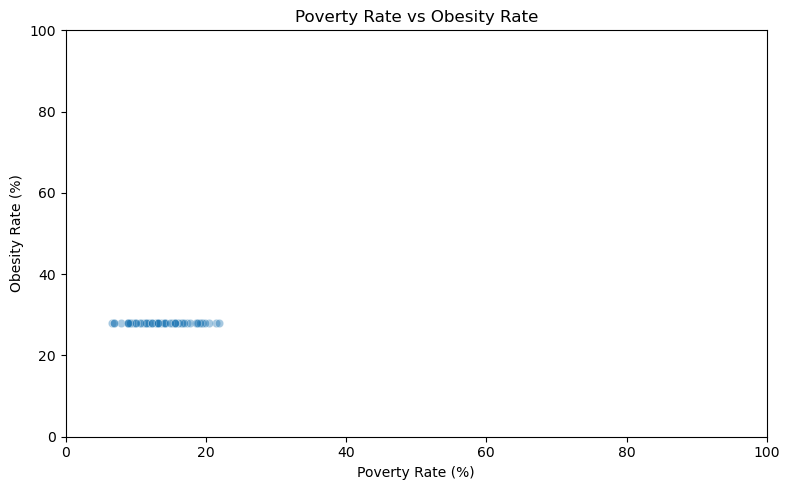

In [26]:
# Obesity vs Poverty

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_obese_adults22',
    alpha=0.4
)

plt.title('Poverty Rate vs Obesity Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Obesity Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

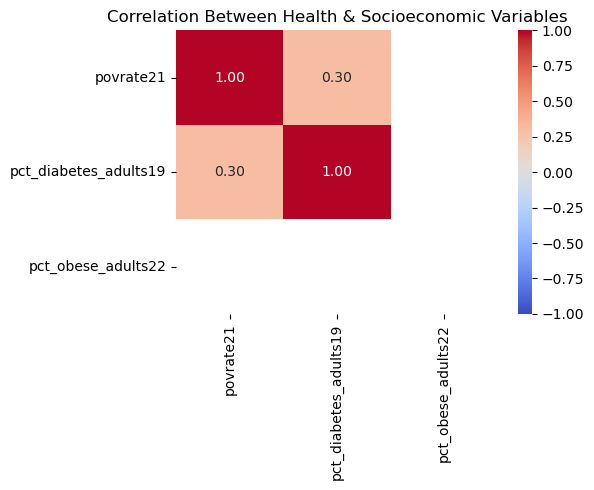

In [27]:
# Correlation Heatmap

cols = [
    'povrate21',
    'pct_diabetes_adults19',
    'pct_obese_adults22'
]

plt.figure(figsize=(6, 5))

sns.heatmap(
    food_env[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Health & Socioeconomic Variables')
plt.tight_layout()
plt.show()

### GIS 

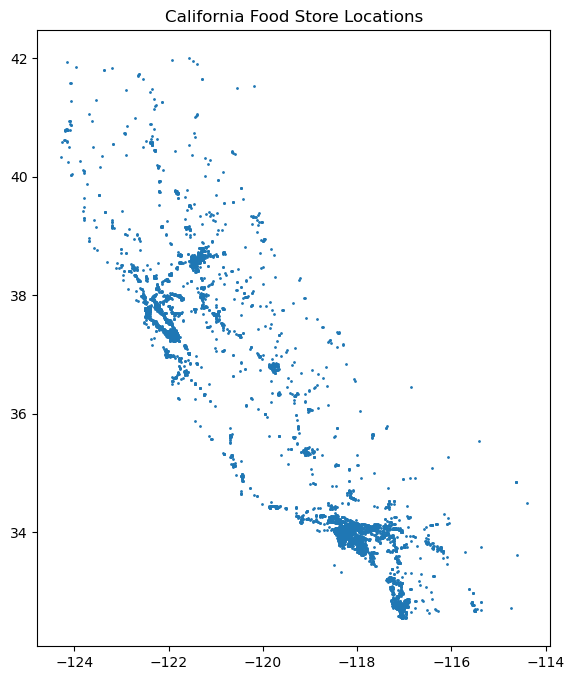

In [28]:
gdf.plot(figsize=(8,8), markersize=1)
plt.title("California Food Store Locations")
plt.show()

## Feature Selection 

Datasets were standardized and merged at the county level within the project pipeline to create a unified modeling dataset. County-level food environment data, Census demographic and socioeconomic indicators, and CDC PLACES health outcomes were integrated into a single feature table. Tract-level food access data was retained for exploratory analysis and descriptive visualizations, but not used directly in the final model due to granularity differences. The final merged dataset was stored in Parquet format to support efficient downstream modeling

The final feature set includes variables from:

    - Food environment data: county-level poverty, adult obesity, and adult diabetes indicators
    - PLACES data: smoking, high blood pressure, physical inactivity, obesity, and diabetes
    - Census data: total population, sex composition, median age, poverty rate, and median income
    - Retail food locations: geospatial food store data retained for mapping and optional future aggregation

### Merging Check 

During pipeline development, county-level join keys were standardized to support integration across food environment, Census, and PLACES datasets. The final merged feature table is now produced directly by the pipeline; however, preliminary merge checks were used during development to verify alignment across county identifiers.

Then either shorten this section or replace it with validation on features.

In [29]:
print(features.shape)
print(features.columns.tolist())
print(features[["county", "state"]].head())

(58, 28)
['state', 'county', 'urban_share', 'population_2010', 'avg_poverty_rate', 'avg_median_family_income', 'low_income_tracts_count', 'lila_1_10_count', 'lila_half_10_count', 'lila_1_20_count', 'total_housing_units_no_vehicle', 'total_snap_households', 'tract_count', 'total_population', 'male_population', 'female_population', 'median_age', 'poverty_rate', 'median_income', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity', 'pct_diabetes_adults19', 'pct_obese_adults22', 'povrate21', 'high_food_access_risk']
      county       state
0    alameda  california
1     alpine  california
2     amador  california
3      butte  california
4  calaveras  california


## Modeling Prep